# Steam — essais du vendredi
Carnet de recherche à reprendre. Deux questions : quel % d’avis positifs ? Quelle tranche de propriétaires estimés ?

Ce notebook est volontairement exploratoire : noms provisoires, copier-coller, paramètres dispersés et exports fragiles.
Il peut être exécuté de haut en bas, mais ce n’est pas encore un programme exploitable.
Les cellules ne constituent pas une architecture recommandée. Conserver une copie avant modification.

Le CSV est une photographie du catalogue ; les mesures sont rétrospectives. `estimated_owners` ne compte pas les joueurs actifs.
Lancer Jupyter depuis le dossier `etudiant`, puis ouvrir ce notebook situé à sa racine.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, f1_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

df = pd.read_csv('data/games.csv')
df.head()

,appid,name,release_date,required_age,price,dlc_count,windows,mac,linux,achievements,genres,positive,negative,pct_pos_total,num_reviews_total,estimated_owners
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,True,False,True,1,"['Action', 'Free To Play']",7480813,1135108,86,8632939,100000000 - 200000000
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,True,False,False,37,"['Action', 'Adventure', 'Massively Multiplayer...",1487960,1024436,59,2513842,50000000 - 100000000
2,570,Dota 2,2013-07-09,0,0.00,2,True,True,True,0,"['Action', 'Strategy', 'Free To Play']",1998462,451338,81,2452595,200000000 - 500000000
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,True,False,False,77,"['Action', 'Adventure']",1719950,250012,87,1803832,50000000 - 100000000
4,488824,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,19.99,9,True,False,False,0,['Action'],312816,64201,84,1168404,0 - 20000


In [2]:
df.shape, df.dtypes, df.isna().sum()

((94948, 16),
 appid                  int64
 name                  object
 release_date          object
 required_age           int64
 price                float64
 dlc_count              int64
 windows                 bool
 mac                     bool
 linux                   bool
 achievements           int64
 genres                object
 positive               int64
 negative               int64
 pct_pos_total          int64
 num_reviews_total      int64
 estimated_owners      object
 dtype: object,
 appid                0
 name                 2
 release_date         0
 required_age         0
 price                0
 dlc_count            0
 windows              0
 mac                  0
 linux                0
 achievements         0
 genres               0
 positive             0
 negative             0
 pct_pos_total        0
 num_reviews_total    0
 estimated_owners     0
 dtype: int64)

## D’abord regarder ce qu’on a
Les gros jeux vont probablement écraser les graphiques… on verra. Les prix sont ceux du CSV ; la devise n’est pas documentée ici.

In [3]:
df[['price', 'dlc_count', 'achievements', 'positive', 'negative', 'pct_pos_total']].describe()

,price,dlc_count,achievements,positive,negative,pct_pos_total
count,94948.000000,94948.000000,94948.000000,9.494800e+04,9.494800e+04,94948.000000
mean,6.911444,0.563203,19.543729,1.217905e+03,2.021265e+02,44.630261
std,13.071148,14.915685,159.798834,3.097974e+04,5.955813e+03,40.837047
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-1.000000
25%,0.990000,0.000000,0.000000,0.000000e+00,0.000000e+00,-1.000000
50%,3.990000,0.000000,2.000000,8.000000e+00,2.000000e+00,58.000000
75%,9.990000,0.000000,19.000000,5.100000e+01,1.500000e+01,84.000000
max,999.980000,3427.000000,9821.000000,7.480813e+06,1.135108e+06,100.000000


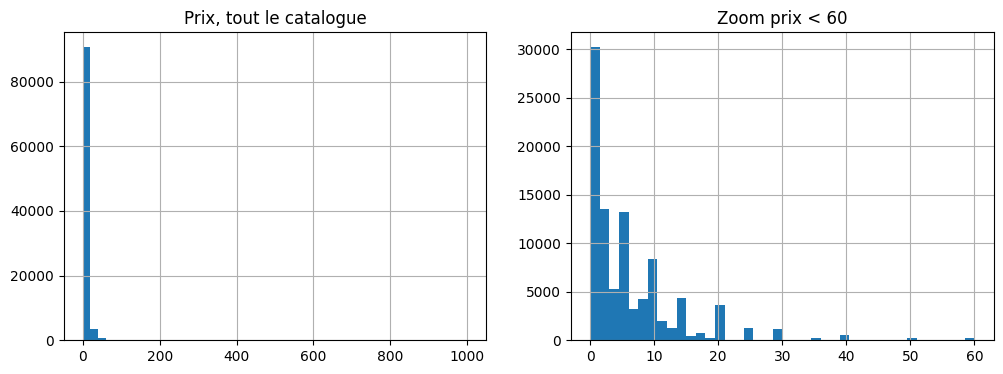

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['price'].hist(bins=50, ax=ax[0]); ax[0].set_title('Prix, tout le catalogue')
df.loc[df.price < 60, 'price'].hist(bins=40, ax=ax[1]); ax[1].set_title('Zoom prix < 60')
plt.show()

In [5]:
df.sort_values('positive', ascending=False)[['name', 'positive', 'negative', 'estimated_owners']].head(12)

,name,positive,negative,estimated_owners
0,Counter-Strike 2,7480813,1135108,100000000 - 200000000
2,Dota 2,1998462,451338,200000000 - 500000000
3,Grand Theft Auto V Legacy,1719950,250012,50000000 - 100000000
1,PUBG: BATTLEGROUNDS,1487960,1024436,50000000 - 100000000
10,Terraria,1344773,34460,20000000 - 50000000
8,Tom Clancy's Rainbow Six® Siege,1152763,218446,20000000 - 50000000
12,Garry's Mod,1106689,36727,20000000 - 50000000
14,Black Myth: Wukong,1098373,37811,50000000 - 100000000
11,Rust,1043708,152272,20000000 - 50000000
9,Team Fortress 2,1025633,120619,20000000 - 50000000


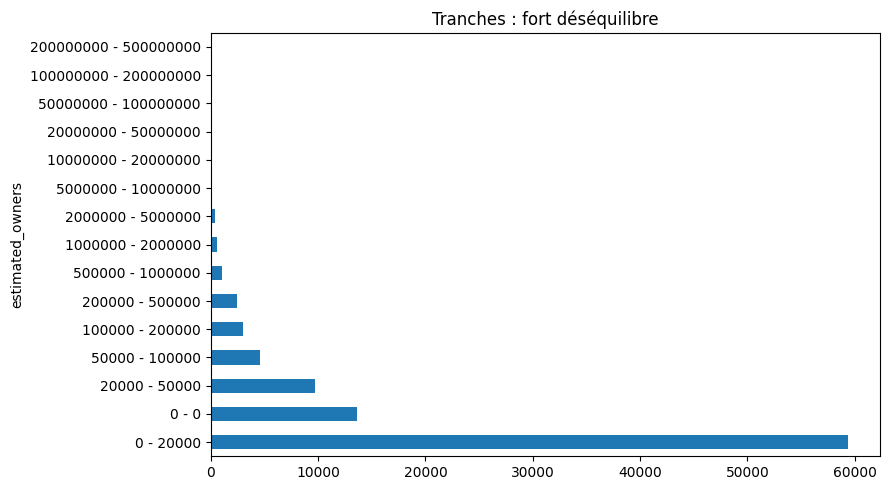

In [6]:
df['estimated_owners'].value_counts().plot.barh(figsize=(9, 5), title='Tranches : fort déséquilibre')
plt.tight_layout(); plt.show()

## Audit avant nettoyage — pas de suppression aveugle
Distinguer absent, sentinelle, zéro valide, valeur extrême et erreur. Ne pas remplacer une cible absente par zéro.
Les lignes ayant le même appid ne peuvent pas traverser les deux côtés du split. Le vrai CSV est contrôlé ici ;
la petite table ci-dessous est **artificielle** et sert uniquement à expérimenter les défauts.

In [7]:
audit = pd.DataFrame({
    'manquants': df.isna().sum(),
    'types': df.dtypes.astype(str)
})
display(audit)
print('Doublons appid :', df.appid.duplicated().sum())
print('Âges sentinelles :', (df.required_age < 0).sum())
print('Dates illisibles :', pd.to_datetime(df.release_date, errors='coerce').isna().sum())
assert df.appid.notna().all() and not df.appid.duplicated().any()

,manquants,types
appid,0,int64
name,2,object
release_date,0,object
required_age,0,int64
price,0,float64
dlc_count,0,int64
windows,0,bool
mac,0,bool
linux,0,bool
achievements,0,int64


Doublons appid : 0
Âges sentinelles : 1
Dates illisibles : 0


In [8]:
essai_sale = pd.DataFrame({'appid':[1, 1, 2, 3], 'price':['0', '0', 'gratuit', None],
                           'required_age':[0, 0, -1, 18],
                           'genres':["[' Action ', 'Indie', 'Action']", "['Action']", '[]', None]})
prix_parse = pd.to_numeric(essai_sale.price, errors='coerce')
print('Erreurs à refuser (pas de zéro inventé) :', (essai_sale.price.notna() & prix_parse.isna()).tolist())
print('Doublons à investiguer :', essai_sale.appid.duplicated(keep=False).tolist())
display(essai_sale)

Erreurs à refuser (pas de zéro inventé) : [False, False, True, False]
Doublons à investiguer : [True, True, False, False]


,appid,price,required_age,genres
0,1,0,0,"[' Action ', 'Indie', 'Action']"
1,1,0,0,['Action']
2,2,gratuit,-1,[]
3,3,None,18,None


,price,dlc_count,achievements
0.00,0.00,0.0,0.0
0.50,3.99,0.0,2.0
0.95,19.99,2.0,56.0
0.99,39.99,7.0,100.0
1.00,999.98,3427.0,9821.0


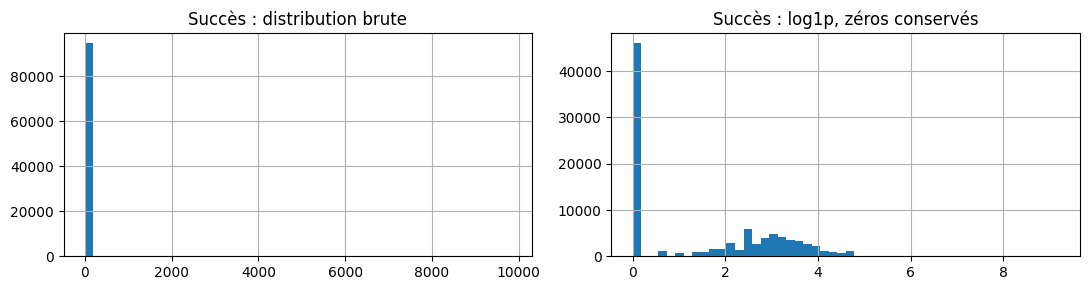

In [9]:
display(df[['price','dlc_count','achievements']].quantile([0, .5, .95, .99, 1]))
fig, ax = plt.subplots(1,2,figsize=(11,3))
df.achievements.hist(bins=50, ax=ax[0]); ax[0].set_title('Succès : distribution brute')
np.log1p(df.achievements).hist(bins=50, ax=ax[1]); ax[1].set_title('Succès : log1p, zéros conservés')
plt.tight_layout(); plt.show()

### Valeurs extrêmes : explorer n'autorise pas à supprimer
Un prix très élevé ou de nombreux succès peuvent être réels. Ici, nous conservons ces jeux.
Si vous testez un écrêtage ou une normalisation, apprendre leurs paramètres uniquement sur le train.
La médiane d'imputation et le regroupement des genres rares sont eux aussi appris après le split.
Les indicateurs de valeurs manquantes et les colonnes entièrement vides doivent rester gérables à l'inférence.

## Le pourcentage, quelle définition ?
`pct_pos_total` fournit déjà un pourcentage. `-1` est traité comme indisponible dans ce TP.
Le ratio des deux compteurs n’est pas forcément identique : on ne mélange pas deux définitions de cible.
On garde `pct_pos_total` et au moins 10 avis selon `num_reviews_total` : convention pédagogique, à documenter.

In [10]:
tmp = df[df.positive + df.negative > 0].copy()
tmp['ratio_calcule'] = 100 * tmp.positive / (tmp.positive + tmp.negative)
tmp[['name', 'ratio_calcule', 'pct_pos_total']].head(10)

,name,ratio_calcule,pct_pos_total
0,Counter-Strike 2,86.825460,86
1,PUBG: BATTLEGROUNDS,59.224740,59
2,Dota 2,81.576537,81
3,Grand Theft Auto V Legacy,87.308791,87
4,Tom Clancy's Rainbow Six® Siege,82.971325,84
5,Tom Clancy's Rainbow Six® Siege,82.963394,84
6,Tom Clancy's Rainbow Six® Siege,82.959011,84
7,Tom Clancy's Rainbow Six® Siege,82.969804,84
8,Tom Clancy's Rainbow Six® Siege,84.069095,84
9,Team Fortress 2,89.477096,89


Lignes pour la régression : 55373


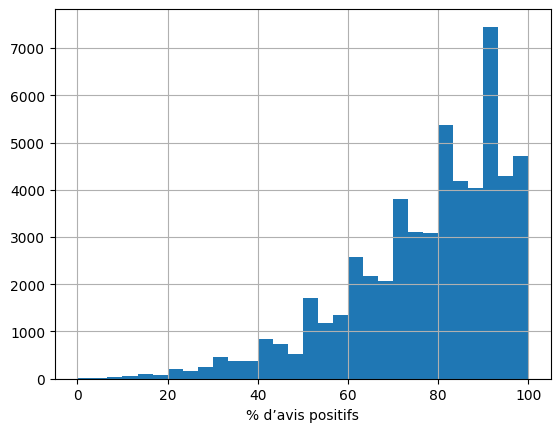

In [11]:
d = df[(df.pct_pos_total >= 0) & (df.pct_pos_total <= 100) & (df.num_reviews_total >= 10)].copy()
print('Lignes pour la régression :', len(d))
d.pct_pos_total.hist(bins=30); plt.xlabel('% d’avis positifs'); plt.show()

## Préparer vraiment les entrées
On combine une variable catégorielle principale avec le nombre de genres et trois indicateurs multi-genres.
Nettoyage des espaces, casse et doublons sans modifier l'ordre des genres. Les plateformes deviennent aussi un compte.
Les mois sont codés sur un cercle : décembre et janvier sont proches. Aucune ancienneté calculée avec la date du jour.
Les variables très asymétriques passent en log1p, qui conserve les zéros. Pour une forêt, une transformation monotone
ne garantit pas un gain : le but est d'expliciter et de tester la préparation, pas de promettre un meilleur score.
Les cibles, appid et compteurs d'avis restent exclus des features.

In [12]:
# Préparation exploratoire : plusieurs décisions à documenter
import ast
d['genres_nettoyes'] = d.genres.fillna('[]').apply(
    lambda s: list(dict.fromkeys(g.strip().casefold() for g in ast.literal_eval(s) if g.strip())))
d['genre'] = d.genres_nettoyes.apply(lambda gs: gs[0] if gs else 'unknown')
d['genre_count'] = d.genres_nettoyes.map(len)
for genre in ['indie', 'action', 'adventure']:
    d['is_' + genre] = d.genres_nettoyes.apply(lambda gs: float(genre in gs))
d.loc[d.required_age < 0, 'required_age'] = np.nan
for source, dest in [('price','log_price'), ('dlc_count','log_dlc_count'), ('achievements','log_achievements')]:
    d[dest] = np.log1p(d[source])
dates = pd.to_datetime(d.release_date, errors='coerce')
d['release_year'] = dates.dt.year
d['month_sin'] = np.sin(2 * np.pi * dates.dt.month / 12)
d['month_cos'] = np.cos(2 * np.pi * dates.dt.month / 12)
d['platform_count'] = d[['windows','mac','linux']].astype(float).sum(axis=1)
d['is_free'] = (d.price == 0).astype(float).mask(d.price.isna())
num = ['log_price','required_age','log_dlc_count','log_achievements','windows','mac','linux',
       'platform_count','release_year','month_sin','month_cos','is_free','genre_count','is_indie','is_action','is_adventure']
X = d[num + ['genre']]
y = d["pct_pos_total"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

In [13]:
prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median', add_indicator=True, keep_empty_features=True), num),
    ('genre', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10, sparse_output=False), ['genre'])
])
m = make_pipeline(prep, DummyRegressor(strategy='mean'))
m.fit(X_train, y_train)
print('MAE baseline', mean_absolute_error(y_test, m.predict(X_test)))

MAE baseline 13.943595983981666


### Que retient le prétraitement ?
Afficher les médianes apprises sur le train et les groupes rares (moins de 10 occurrences d'entraînement).
Une catégorie inconnue rejoint le groupe rare s'il existe ; sinon son bloc est encodé à zéro.
Les valeurs manquantes sont imputées, avec indicateurs pour les colonnes manquantes observées au fit.
Aucune médiane, catégorie ou fréquence du test n'est apprise.

In [14]:
display(pd.Series(prep.named_transformers_['num'].statistics_, index=num, name='médianes du train'))
print('Genres rares :', prep.named_transformers_['genre'].infrequent_categories_)
sonde = X_test.head(2).copy()
sonde.loc[:, 'genre'] = 'genre jamais vu'
sonde.loc[:, 'log_price'] = np.nan
print('Shape avant/après :', sonde.shape, prep.transform(sonde).shape)
assert np.isfinite(prep.transform(sonde)).all()

log_price           1.790091e+00
required_age        0.000000e+00
log_dlc_count       0.000000e+00
log_achievements    2.397895e+00
windows             1.000000e+00
mac                 0.000000e+00
linux               0.000000e+00
platform_count      1.000000e+00
release_year        2.021000e+03
month_sin          -2.449294e-16
month_cos           6.123234e-17
is_free             0.000000e+00
genre_count         3.000000e+00
is_indie            1.000000e+00
is_action           0.000000e+00
is_adventure        0.000000e+00
Name: médianes du train, dtype: float64

Genres rares : [array(['animation & modeling', 'utilities'], dtype=object)]
Shape avant/après : (2, 17) (2, 35)


### Essai forêt — pas de recherche d’hyperparamètres pour le moment
Une MAE s’exprime ici en points de pourcentage. On réutilise le même découpage pour comparer à la baseline.

In [15]:
m = make_pipeline(ColumnTransformer([
    ('num', SimpleImputer(strategy='median', add_indicator=True, keep_empty_features=True), num),
    ('genre', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10, sparse_output=False), ['genre'])
]), RandomForestRegressor(n_estimators=40, max_depth=12, min_samples_leaf=5, n_jobs=1))
m.fit(X_train, y_train)
p = m.predict(X_test)
print('MAE', mean_absolute_error(y_test, p), 'R²', r2_score(y_test, p))

MAE 12.849788536431891 R² 0.12181081492436463


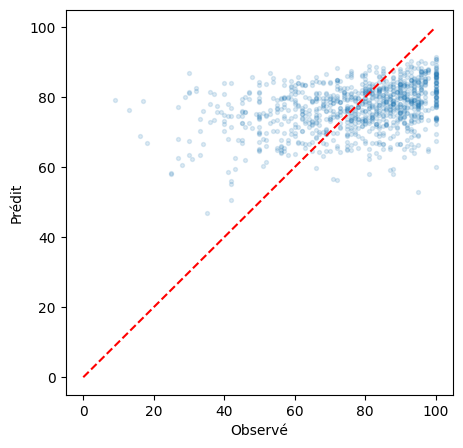

In [16]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test.iloc[:1000], p[:1000], alpha=.15, s=8)
plt.plot([0,100], [0,100], 'r--'); plt.xlabel('Observé'); plt.ylabel('Prédit'); plt.show()

In [17]:
erreurs = pd.DataFrame({'observe': y_test, 'predit': p})
erreurs['erreur'] = abs(erreurs.observe - erreurs.predit)
erreurs.sort_values('erreur', ascending=False).head(10)

,observe,predit,erreur
51239,0,83.554289,83.554289
54024,0,79.102716,79.102716
42904,5,83.453401,78.453401
47902,0,75.775368,75.775368
53800,10,84.229759,74.229759
41580,9,82.270458,73.270458
42894,0,70.669724,70.669724
53193,9,79.198544,70.198544
53042,0,69.483591,69.483591
53523,9,78.405092,69.405092


## Deuxième piste : la tranche de propriétaires
On conserve les libellés des tranches, sans les convertir en nombres continus.
Convention du TP : exclure `0 - 0`, dont la signification n’est pas documentée, et les tranches de moins de 5 jeux.
Elles sont hors du périmètre de cette baseline, pas regroupées silencieusement.
Le seuil évite notamment le problème des deux classes à un seul exemple lors du split stratifié.

In [18]:
d2 = df[df.estimated_owners != '0 - 0'].copy()
vc = d2.estimated_owners.value_counts()
print('Classes exclues car trop rares :', vc[vc < 5].to_dict())
d2 = d2[d2.estimated_owners.isin(vc[vc >= 5].index)].copy()
print(len(d2), 'jeux ;', d2.estimated_owners.nunique(), 'classes')

Classes exclues car trop rares : {'200000000 - 500000000': 1, '100000000 - 200000000': 1}
81290 jeux ; 12 classes


In [19]:
# Préparation exploratoire recopiée pour la deuxième tâche
import ast
d2['genres_nettoyes'] = d2.genres.fillna('[]').apply(
    lambda s: list(dict.fromkeys(g.strip().casefold() for g in ast.literal_eval(s) if g.strip())))
d2['genre'] = d2.genres_nettoyes.apply(lambda gs: gs[0] if gs else 'unknown')
d2['genre_count'] = d2.genres_nettoyes.map(len)
for genre in ['indie', 'action', 'adventure']:
    d2['is_' + genre] = d2.genres_nettoyes.apply(lambda gs: float(genre in gs))
d2.loc[d2.required_age < 0, 'required_age'] = np.nan
for source, dest in [('price','log_price'), ('dlc_count','log_dlc_count'), ('achievements','log_achievements')]:
    d2[dest] = np.log1p(d2[source])
dates = pd.to_datetime(d2.release_date, errors='coerce')
d2['release_year'] = dates.dt.year
d2['month_sin'] = np.sin(2 * np.pi * dates.dt.month / 12)
d2['month_cos'] = np.cos(2 * np.pi * dates.dt.month / 12)
d2['platform_count'] = d2[['windows','mac','linux']].astype(float).sum(axis=1)
d2['is_free'] = (d2.price == 0).astype(float).mask(d2.price.isna())
num = ['log_price','required_age','log_dlc_count','log_achievements','windows','mac','linux',
       'platform_count','release_year','month_sin','month_cos','is_free','genre_count','is_indie','is_action','is_adventure']
X = d2[num + ['genre']]
y = d2["estimated_owners"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, stratify=y)

In [20]:
b = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print('Baseline accuracy', accuracy_score(y_test, b.predict(X_test)))
print('Baseline F1 macro', f1_score(y_test, b.predict(X_test), average='macro', zero_division=0))

Baseline accuracy 0.7304711526633042
Baseline F1 macro 0.07035378308570887


In [21]:
m = make_pipeline(ColumnTransformer([
    ('num', SimpleImputer(strategy='median', add_indicator=True, keep_empty_features=True), num),
    ('genre', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10, sparse_output=False), ['genre'])
]), RandomForestClassifier(n_estimators=40, max_depth=12, min_samples_leaf=5, n_jobs=1))
m.fit(X_train, y_train)
p = m.predict(X_test)
print('Accuracy', accuracy_score(y_test, p))
print('F1 macro', f1_score(y_test, p, average='macro', zero_division=0))
print(classification_report(y_test, p, zero_division=0))

Accuracy 0.7317013162750646
F1 macro 0.08124497963707975
                      precision    recall  f1-score   support

           0 - 20000       0.74      1.00      0.85     11876
     100000 - 200000       0.07      0.00      0.00       602
   1000000 - 2000000       0.27      0.03      0.05       115
 10000000 - 20000000       0.00      0.00      0.00         8
       20000 - 50000       0.19      0.00      0.01      1938
     200000 - 500000       0.21      0.03      0.06       495
   2000000 - 5000000       0.00      0.00      0.00        75
 20000000 - 50000000       0.00      0.00      0.00         5
      50000 - 100000       0.00      0.00      0.00       912
    500000 - 1000000       0.09      0.00      0.01       208
  5000000 - 10000000       0.00      0.00      0.00        22
50000000 - 100000000       0.00      0.00      0.00         2

            accuracy                           0.73     16258
           macro avg       0.13      0.09      0.08     16258
        wei

### Est-ce que le modèle prédit toujours la petite tranche ?
L’accuracy peut donner une impression trompeuse. Regarder les rappels et les effectifs par tranche.
Ne pas régler le modèle à répétition sur le test ; ici la comparaison se limite à deux candidats fixés (dummy et forêt).

In [22]:
pd.crosstab(y_test, pd.Series(p, index=y_test.index, name='prédit'), normalize='index').round(2)

prédit,0 - 20000,100000 - 200000,1000000 - 2000000,20000 - 50000,200000 - 500000,2000000 - 5000000,50000 - 100000,500000 - 1000000
estimated_owners,,,,,,,,
0 - 20000,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
100000 - 200000,0.96,0.00,0.00,0.01,0.02,0.00,0.0,0.00
1000000 - 2000000,0.78,0.00,0.03,0.02,0.10,0.06,0.0,0.02
10000000 - 20000000,0.50,0.25,0.25,0.00,0.00,0.00,0.0,0.00
20000 - 50000,0.99,0.00,0.00,0.00,0.00,0.00,0.0,0.00
200000 - 500000,0.93,0.01,0.00,0.02,0.03,0.00,0.0,0.00
2000000 - 5000000,0.75,0.03,0.03,0.00,0.16,0.00,0.0,0.04
20000000 - 50000000,0.60,0.00,0.00,0.00,0.40,0.00,0.0,0.00
50000 - 100000,0.98,0.00,0.00,0.01,0.01,0.00,0.0,0.00


## Export vite fait avant de partir
J’ai appelé mes deux modèles `m`… est-ce vraiment le bon fichier pour les deux usages ?

In [23]:
Path('artifacts').mkdir(exist_ok=True)
joblib.dump(m, 'artifacts/modele.joblib')
pd.DataFrame({'observe': y_test, 'prediction': p}).to_csv('artifacts/resultats.csv', index=False)
print('Sauvegardé !')

Sauvegardé !

## Notes pour la reprise
- Les résultats changent quand je relance. Qu’ai-je oublié de fixer ?
- Tout dépend de l’ordre des cellules et du dossier de lancement.
- Où est passée la forêt de régression après le deuxième entraînement ?
- Le prétraitement est copié plusieurs fois ; un changement sera-t-il appliqué partout ?
- Où retrouver les paramètres et les jeux du split ?
- Comment prédire sans relancer l’entraînement ?
- Que se passe-t-il si le prix contient « gratuit » ?

**Manipulation à faire sur une copie :** après le Run All, relancer uniquement la cellule de MAE de régression.
Observer que `y_test` et `p` contiennent désormais des classes. Expliquer le lien avec l’état du kernel.
Puis redémarrer le kernel. Le TP consiste à faire disparaître cette dépendance implicite dans le projet extrait.